# Agentic AI Basics

In [1]:
import os
import json
import logging

from openai import OpenAI
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from agents import Agent, Runner, function_tool, trace
from fastmcp import Client
import asyncio
from agents import Agent, Runner
from agents.mcp import MCPServerSse
import docx
import pdfplumber
import subprocess

from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

In [2]:
def setup_environment():
    import sys
    sys.path.append('C:\\gitworkspace\\aimldemo\\jupyterworkapce')
    import stratup_env_setup
    stratup_env_setup.set_env()

In [3]:
setup_environment()

In [4]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

In [5]:
response = llm.invoke("One sentence about Piscataway, NJ")

In [6]:
response.content

'Piscataway, NJ, is a diverse township known for its rich history, vibrant community, and as the home of Rutgers University’s Busch Campus.'

In [7]:
# Logging configuration
logger = logging.getLogger("agentic_ai")
logger.setLevel(logging.INFO)

handler = logging.StreamHandler()
formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
handler.setFormatter(formatter)

logger.addHandler(handler)

# Basic Agent

In [8]:
def classify_input(text):

    logger.info("Router Agent: classifying input...")

    client = OpenAI()

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        temperature=0,
        messages=[
            {
                "role": "system",
                "content": """
                Classify the user input as either:
                - company
                - town

                Return ONLY JSON like:
                {"route":"company"}
                or
                {"route":"town"}
                """
            },
            {
                "role": "user",
                "content": text
            }
        ]
    )

    content = response.choices[0].message.content

    route = json.loads(content)["route"]

    logger.info(f"Router Agent: classified as {route}")

    return route

In [9]:
company_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
        You are a company research assistant.
        Given a company name, output exactly 3 bullet points describing the company.
        """
    ),
    ("user", "{company}")
])

company_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

company_chain = company_prompt | company_llm

In [10]:
town_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
        You are a geography assistant.
        Given a town name, output exactly 3 bullet points.
        Each bullet should be one sentence about the town.
        """
    ),
    ("user", "{town}")
])

town_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

town_chain = town_prompt | town_llm

In [11]:
def run_agentic_flow(text):

    logger.info(f"Received input: {text}")

    route = classify_input(text)

    if route == "company":

        logger.info("Routing to Company Agent")

        result = company_chain.invoke({"company": text})

    else:

        logger.info("Routing to Town Agent")

        result = town_chain.invoke({"town": text})

    logger.info("Final response generated")

    return result.content

In [12]:
run_agentic_flow("Microsoft")

2026-03-25 10:20:20,550 | INFO | Received input: Microsoft
2026-03-25 10:20:20,552 | INFO | Router Agent: classifying input...
2026-03-25 10:20:22,384 | INFO | Router Agent: classified as company
2026-03-25 10:20:22,384 | INFO | Routing to Company Agent
2026-03-25 10:20:25,794 | INFO | Final response generated


'- Microsoft is a multinational technology company known for developing software products, including the Windows operating system and the Microsoft Office suite, which are widely used across personal and business environments.\n- The company has a significant presence in cloud computing through its Azure platform, offering a range of services such as data storage, analytics, and machine learning to businesses and developers.\n- Microsoft is also involved in hardware production, with products like the Surface line of tablets and laptops, as well as the Xbox gaming console, catering to both productivity and entertainment markets.'

In [13]:
run_agentic_flow("Piscataway")

2026-03-25 10:20:38,117 | INFO | Received input: Piscataway
2026-03-25 10:20:38,118 | INFO | Router Agent: classifying input...
2026-03-25 10:20:40,299 | INFO | Router Agent: classified as town
2026-03-25 10:20:40,299 | INFO | Routing to Town Agent
2026-03-25 10:20:43,023 | INFO | Final response generated


'- Piscataway is located in Middlesex County, New Jersey, and is known for its diverse community and rich history.  \n- The town is home to several parks and recreational areas, including the scenic Johnson Park, which offers various outdoor activities.  \n- Piscataway is also recognized for its educational institutions, including a campus of Rutgers University, contributing to its vibrant academic environment.  '

# OpenAI Agent SDK

In [14]:
town_agent = Agent(
    name="Town Agent",
    instructions="""
You are a geography assistant.

When given the name of a town or city:
- Output exactly 3 bullet points
- Each bullet must be one sentence about the town
- Do not output anything else
""",
    model="gpt-4o-mini"
)

In [15]:
with trace("Town Agent Flow"):

    result = await Runner.run(
        town_agent,
        "Piscataway, New Jersey"
    )

print(result.final_output)

- Piscataway is home to Rutgers University, which is the largest institution for higher education in New Jersey.  
- The township encompasses several parks, including the scenic Davidson's Mill Pond Park, which offers recreational activities and nature trails.  
- Piscataway has a rich history, featuring landmarks like the historic Kirkpatrick Chapel, built in the late 1800s.  


# OpenAI Agent Calling MCP Tool

In [17]:
# Initialize OpenAI client
client = OpenAI()


In [18]:
# Connect to MCP server
client = Client("http://localhost:8000/mcp")

In [19]:
import nest_asyncio
nest_asyncio.apply()

from agents import Agent, Runner
from agents.mcp import MCPServerSse, MCPServerSseParams

async def main():
    server = MCPServerSse(
        params=MCPServerSseParams(
            url="http://127.0.0.1:8000/sse"
        ),
        name="weather-mcp",
    )

    agent = Agent(
        name="Weather Assistant",
        instructions="You are a helpful assistant. Use the weather tool when needed.",
        mcp_servers=[server],
    )

    async with server:
        result = await Runner.run(
            agent,
            "What is the weather in London?"
        )
        print(result.final_output)

await main()

Traceback (most recent call last):
  File "C:\Users\jimmy\AppData\Roaming\Python\Python311\site-packages\anyio\_core\_sockets.py", line 182, in try_connect
    stream = await asynclib.connect_tcp(remote_host, remote_port, local_address)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jimmy\AppData\Roaming\Python\Python311\site-packages\anyio\_backends\_asyncio.py", line 2630, in connect_tcp
    await get_running_loop().create_connection(
  File "C:\ProgramData\anaconda3\Lib\asyncio\base_events.py", line 1085, in create_connection
    raise exceptions[0]
  File "C:\ProgramData\anaconda3\Lib\asyncio\base_events.py", line 1069, in create_connection
    sock = await self._connect_sock(
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\asyncio\base_events.py", line 973, in _connect_sock
    await self.sock_connect(sock, address)
  File "C:\ProgramData\anaconda3\Lib\asyncio\selector_events.py", line 634, in sock_connec

# CV-Job Search Agentic AI Example

In [20]:
@tool
def job_posting_tool(job_link: str) -> str:
    """Extracts structured information from a job posting at the provided URL.

    Args:
        job_link (str): The URL of the job posting.

    Returns:
        str: A structured summary of the job posting's key details.
    """
    completion = client.chat.completions.create(
        model="gpt-4o-search-preview",
        web_search_options={"search_context_size": "medium"},
        messages=[
            {
            "role": "user",
            "content": """
            You are a helpful tool that visits the following job posting and carefully read its contents.  
            Summarize the key details in a clear and concise format, including:
            Visit the provided job posting link, read it thoroughly, and extract and summarize all key information. Include:
            - Job title
            - Company name
            - Location
            - Employment type (full-time, part-time, contract, etc.)
            - Salary or compensation (if available)
            - Required qualifications/skills
            - Primary responsibilities
            - Benefits offered
            - Application instructions
            - Posting date (if available)

            Format
            - Respond with a clear, structured bullet-point list.
            - Use exact factual information from the posting, no rewording beyond making it concise.
            - If the posting is missing, inaccessible, or contains no job details, respond with:
            "Job posting unavailable or contains no job details."

            Do's 
            - Ensure all extracted details are accurate and directly taken from the posting.
            - Keep descriptions short, professional, and easy to scan.
            - Use consistent formatting for all fields (e.g., “Job Title: …”).  
            Don'ts
            - Do not include filler language, speculation, or personal opinions.
            - Do not rewrite or interpret details—only report factual information from the posting.
            """
        },
        {
            "role": "system",
            "content": f"Visit this job posting and extract details:\n{job_link}"
        }
    ],
    )
    return completion.choices[0].message.content
    

In [21]:
@tool
def extract_cv_text(file_path: str) -> str:
    """Extracts the text content from a CV file in PDF, DOCX, or DOC format. The CV should be inside the same folder that this notebook is in.

    Args:
        file_path (str): The local file path to the CV document. 

    Returns:
        str: The extracted plain text from the CV, or an error message if the format is unsupported or cannot be read.
    """
    
    ext = os.path.splitext(file_path)[-1].lower()
    
    if ".docx" in ext:
        try:
            doc = docx.Document(file_path)
            text = [para.text for para in doc.paragraphs]
            return '\n'.join(text)
        except Exception as e:
            return f"Error reading the .docx file: {e}"
        
    elif ".pdf" in ext:
        try:
            text = []
            with pdfplumber.open(file_path) as pdf:
                for page in pdf.pages:
                    page_text = page.extract_text()
                    if page_text:
                        text.append(page_text)
            return '\n'.join(text)
        except Exception as e:
            return f"Error reading the .pdf file: {e}"
    
    elif ".doc" in ext:
        try:
            temp_docx = file_path + ".temp.docx"
            subprocess.run(['soffice', '--headless', '--convert-to', 'docx', '--outdir', os.path.dirname(file_path), file_path], check=True)
            
            doc = docx.Document(os.path.splitext(file_path)[0] + ".docx")
            text = [para.text for para in doc.paragraphs]
            
            os.remove(os.path.splitext(file_path)[0] + ".docx")
            return '\n'.join(text)
        except Exception as e:
            return f"Error reading .doc file: {e}"
    
    else:
        return "Unsupported file format. Please use .pdf, .docx, or .doc."

In [22]:
tools = [job_posting_tool, extract_cv_text]
tool_node = ToolNode(tools=tools)

In [23]:
llm_with_tools = llm.bind_tools(tools)

In [28]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

sys_msg = SystemMessage(content="""
You are an expert career assistant that helps the user with questions related to jobs, careers, and applications.

Your key capabilities:
- You have access to the user's CV and can read its contents using the `extract_cv_text` tool.
- You can look up and extract details from job postings using the `job_posting_tool`.
- You can compare the user's CV against one or more job postings to determine suitability and provide tailored advice.
- You can suggest improvements to the CV for better alignment with target roles.

When answering:
1. First, think step-by-step about the user's request.
2. If the task requires reading the CV, call the CV extraction tool before answering.
3. If the task involves evaluating job postings, call the job posting tool to gather accurate information before answering.
4. Compare and reason about the information before providing your final response.

Response format:
- Be clear, concise, and structured with bullet points or numbered lists.
- Use section headers when possible (e.g., "Strengths", "Weaknesses", "Recommendations").
- Support your statements with evidence from the CV or job postings.
- Avoid vague language—be specific and factual.

Constraints:
- Do not invent or guess details about the user's experience or job postings.
- Only use information available in the CV, job postings, or provided context.
- Keep your tone professional, friendly, and supportive.


""")

In [29]:
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

In [30]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display

builder = StateGraph(MessagesState)

builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)

builder.add_edge("tools", "assistant")
react_graph = builder.compile()

C:\Users\jimmy\AppData\Roaming\Python\Python311\site-packages\websockets\legacy\__init__.py:6: DeprecationWarning: websockets.legacy is deprecated; see https://websockets.readthedocs.io/en/stable/howto/upgrade.html for upgrade instructions
  warnings.warn(  # deprecated in 14.0 - 2024-11-09


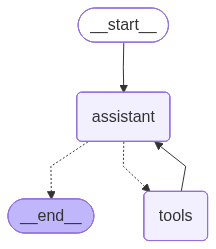

In [31]:
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [36]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
react_graph_memory = builder.compile(checkpointer=memory)

In [37]:
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [38]:
config = {"configurable": {"thread_id": "1"}}

In [39]:
messages = [HumanMessage(content="""
        Can you take a look at my CV ath the location 'cv-template2.pdf'  and these 3 job applications and tell me whichone is the most suitable for my expiriance: 
        
        'https://www.indeed.com/viewjob?jk=247e94f9a28c544f&tk=1isdf5na1h72t810&from=serp&vjs=3',
        'https://www.indeed.com/viewjob?jk=744686732444f370&tk=1isns1midj72r8b4&from=serp&vjs=3',
        'https://www.indeed.com/viewjob?jk=01e2f371f220e42a&tk=1isns1midj72r8b4&from=serp&vjs=3'
        
        """)]

In [40]:
result = react_graph_memory.invoke({"messages": messages}, config)

In [41]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================


        Can you take a look at my CV ath the location 'cv-template2.pdf'  and these 3 job applications and tell me whichone is the most suitable for my expiriance: 
        
        'https://www.indeed.com/viewjob?jk=247e94f9a28c544f&tk=1isdf5na1h72t810&from=serp&vjs=3',
        'https://www.indeed.com/viewjob?jk=744686732444f370&tk=1isns1midj72r8b4&from=serp&vjs=3',
        'https://www.indeed.com/viewjob?jk=01e2f371f220e42a&tk=1isns1midj72r8b4&from=serp&vjs=3'
        
        
================================== Ai Message ==================================
Tool Calls:
  extract_cv_text (call_pBoqwPgLPbeEJysOakgzwQDg)
 Call ID: call_pBoqwPgLPbeEJysOakgzwQDg
  Args:
    file_path: cv-template2.pdf
  job_posting_tool (call_6BeJWYZFQVnkxHebqaV9SrV6)
 Call ID: call_6BeJWYZFQVnkxHebqaV9SrV6
  Args:
    job_link: https://www.indeed.com/viewjob?jk=247e94f9a28c544f&tk=1isdf5na1h72t810&from=serp&vjs=3
  job_pos

In [42]:
messages = [HumanMessage(content="""
        I’ve attached my CV (cv-template2.pdf). I’m targeting entry-level data-analysis roles. Please review the document and provide:
1. A bullet-point list of my key strengths and accomplishments that align with data-analysis positions.
2. A bullet-point list of weaknesses or areas for improvement, grouped by content, formatting, and wording.
3. Three actionable suggestions to make the CV more compelling for hiring managers and ATS systems.
Please keep the total response under 300 words.
        
        """)]
result = react_graph_memory.invoke({"messages": messages},config)

for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================


        Can you take a look at my CV ath the location 'cv-template2.pdf'  and these 3 job applications and tell me whichone is the most suitable for my expiriance: 
        
        'https://www.indeed.com/viewjob?jk=247e94f9a28c544f&tk=1isdf5na1h72t810&from=serp&vjs=3',
        'https://www.indeed.com/viewjob?jk=744686732444f370&tk=1isns1midj72r8b4&from=serp&vjs=3',
        'https://www.indeed.com/viewjob?jk=01e2f371f220e42a&tk=1isns1midj72r8b4&from=serp&vjs=3'
        
        
================================== Ai Message ==================================
Tool Calls:
  extract_cv_text (call_pBoqwPgLPbeEJysOakgzwQDg)
 Call ID: call_pBoqwPgLPbeEJysOakgzwQDg
  Args:
    file_path: cv-template2.pdf
  job_posting_tool (call_6BeJWYZFQVnkxHebqaV9SrV6)
 Call ID: call_6BeJWYZFQVnkxHebqaV9SrV6
  Args:
    job_link: https://www.indeed.com/viewjob?jk=247e94f9a28c544f&tk=1isdf5na1h72t810&from=serp&vjs=3
  job_pos